<a href="https://colab.research.google.com/github/Dania-Yasir/freight-rate-prediction/blob/main/notebooks/freight_rate_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Freight Rate Prediction

Machine Learning Engineer Assessment

##1. Setup & Imports


In [40]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

## 2. Exploratory Data Analysis

In [41]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

REPO_DIR = Path("freight-rate-prediction")

if not REPO_DIR.exists():
    !git clone https://github.com/Dania-Yasir/freight-rate-prediction.git

DATA_DIR = REPO_DIR / "data"

print("Data directory:", DATA_DIR)
print("Exists:", DATA_DIR.exists())

Data directory: freight-rate-prediction/data
Exists: True


In [42]:
train = pd.read_csv(
    DATA_DIR / "Process" / "train_test_clean.csv"
)

validation = pd.read_csv(
    DATA_DIR / "Process" / "validation_clean.csv"
)

print("Train shape:", train.shape)
print("Validation shape:", validation.shape)

Train shape: (48000, 17)
Validation shape: (12000, 16)


In [43]:
display(train.head())
display(validation.head())

print("\nTrain columns:")
print(train.columns.tolist())

print("\nValidation columns:")
print(validation.columns.tolist())

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate,weight_missing_flag,weight_negative_flag,market_index_missing_flag
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41,0,0,0
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97,0,0,0
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54,0,0,0
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28,0,0,0
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28,0,0,0


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,weight_missing_flag,weight_negative_flag,market_index_missing_flag
0,TE-000001,Baton Rouge,Mobile,30.50134,-92.65374,31.80442,-88.25195,331.4,Flatbed,19958.0,2025-11-01,0.90402,1.86388,0,0,0
1,TE-000002,Savannah,Los Angeles,33.60973,-82.29994,28.56624,-116.70249,2406.2,Reefer,34114.0,2025-11-01,0.92851,1.86240,0,0,0
2,TE-000003,San Francisco,Raleigh,35.19670,-121.69849,35.37376,-77.47605,2846.6,Dry Van,33435.0,2025-11-01,0.88117,1.95480,0,0,0
3,TE-000004,Dayton,Los Angeles,39.87206,-85.62931,28.56624,-116.70249,2261.6,Dry Van,25392.0,2025-11-01,0.89156,2.14579,0,0,0
4,TE-000005,Memphis,San Antonio,35.56802,-89.52871,29.50969,-98.40059,800.4,Flatbed,31532.5,2025-11-01,0.88308,2.22541,1,0,0



Train columns:
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate', 'weight_missing_flag', 'weight_negative_flag', 'market_index_missing_flag']

Validation columns:
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'weight_missing_flag', 'weight_negative_flag', 'market_index_missing_flag']


A few simple visualizations to understand the main relationships in the cleaned training data.

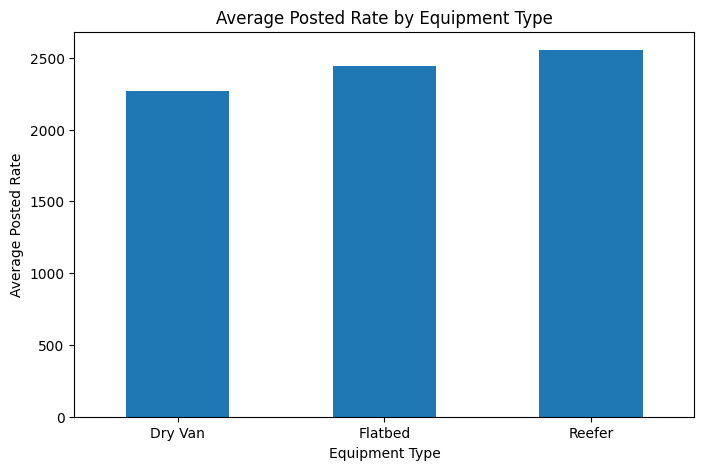

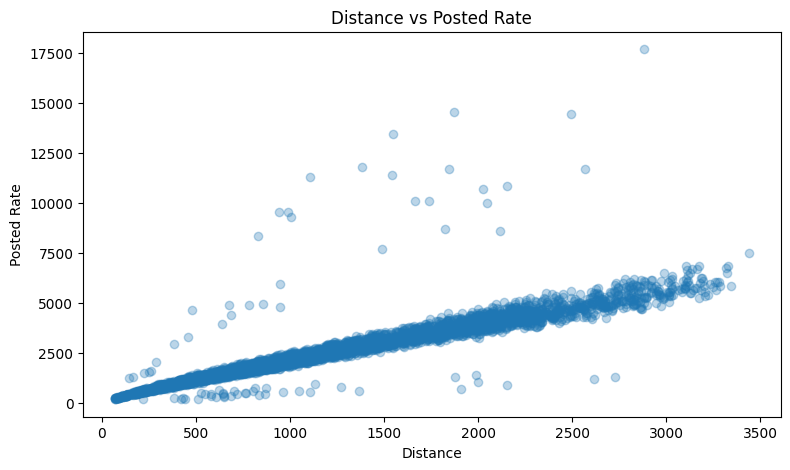

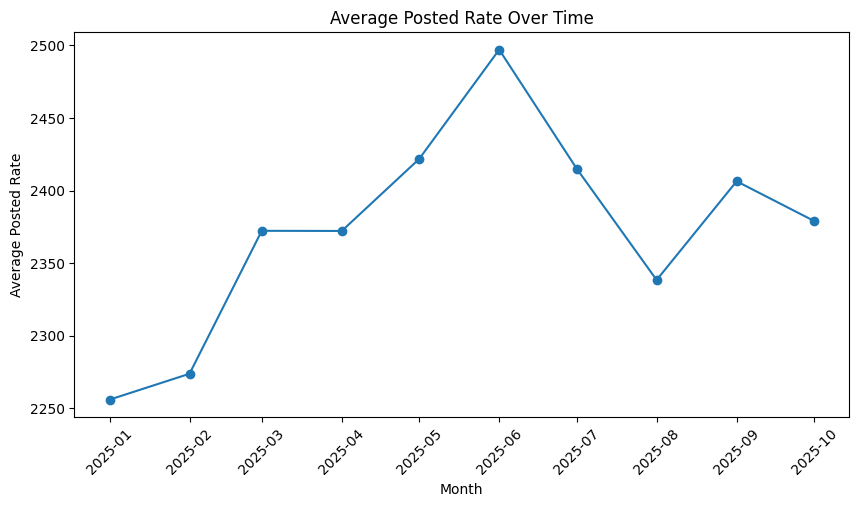

In [44]:

equipment_rates = (
    train.groupby("equipment")["posted_rate"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 5))

equipment_rates.plot(kind="bar")

plt.title("Average Posted Rate by Equipment Type")
plt.xlabel("Equipment Type")
plt.ylabel("Average Posted Rate")

plt.xticks(rotation=0)
plt.show()
sample = train.sample(5000, random_state=42)

plt.figure(figsize=(9, 5))

plt.scatter(
    sample["distance"],
    sample["posted_rate"],
    alpha=0.3
)

plt.title("Distance vs Posted Rate")
plt.xlabel("Distance")
plt.ylabel("Posted Rate")

plt.show()
train["date"] = pd.to_datetime(train["date"])
monthly_rate = (
    train
    .set_index("date")
    .resample("MS")["posted_rate"]
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_rate.index,
    monthly_rate.values,
    marker="o"
)

plt.title("Average Posted Rate Over Time")
plt.xlabel("Month")
plt.ylabel("Average Posted Rate")

plt.xticks(rotation=45)
plt.show()

## 3. Train / Validation Split

Since freight rates vary over time, a time-based split is used instead of a random split.

The most recent month in the labeled development data is held out for validation.  
This better simulates the final task of predicting rates for future loads.

In [45]:
# Make sure date is datetime
train["date"] = pd.to_datetime(train["date"])

# Find the first day of the latest month
split_date = train["date"].max().to_period("M").start_time

# Time-based split
train_df = train[train["date"] < split_date].copy()
valid_df = train[train["date"] >= split_date].copy()

print("Split date:", split_date)

print("\nTraining set:")
print("Shape:", train_df.shape)
print("Date range:", train_df["date"].min(), "to", train_df["date"].max())

print("\nValidation set:")
print("Shape:", valid_df.shape)
print("Date range:", valid_df["date"].min(), "to", valid_df["date"].max())

Split date: 2025-10-01 00:00:00

Training set:
Shape: (43147, 17)
Date range: 2025-01-01 00:00:00 to 2025-09-30 00:00:00

Validation set:
Shape: (4853, 17)
Date range: 2025-10-01 00:00:00 to 2025-10-31 00:00:00


## 4. Feature Engineering

Features are created consistently for the training, local validation, and final prediction datasets.

The original freight information is retained, while additional route and time-based features are derived from the available columns.

In [46]:
TARGET = "posted_rate"
ID_COL = "load_id"

# Use the beginning of the development period as a fixed reference
DATE_ORIGIN = train["date"].min()


def add_features(df):
    df = df.copy()

    # Ensure date is datetime
    df["date"] = pd.to_datetime(df["date"])

    # Route feature
    df["route"] = (
        df["pickup"].astype(str)
        + "__"
        + df["delivery"].astype(str)
    )

    # Time features
    df["month"] = df["date"].dt.month
    df["day_of_week"] = df["date"].dt.dayofweek
    df["days_since_start"] = (
        df["date"] - DATE_ORIGIN
    ).dt.days

    # Geographic features
    df["lat_diff"] = (
        df["delivery_lat"] - df["pickup_lat"]
    ).abs()

    df["lon_diff"] = (
        df["delivery_lon"] - df["pickup_lon"]
    ).abs()

    # Useful interactions
    df["distance_market"] = (
        df["distance"] * df["market_index"]
    )

    df["distance_quote"] = (
        df["distance"] * df["quote_signal"]
    )

    return df

In [47]:
train_fe = add_features(train_df)
valid_fe = add_features(valid_df)
final_fe = add_features(validation)

print("Training:", train_fe.shape)
print("Validation:", valid_fe.shape)
print("Final validation:", final_fe.shape)

Training: (43147, 25)
Validation: (4853, 25)
Final validation: (12000, 24)


In [48]:
TARGET = "posted_rate"
ID_COL = "load_id"

# Columns that should not be used directly as model features
DROP_COLS = [TARGET, ID_COL, "date"]

X_train = train_fe.drop(columns=DROP_COLS)
y_train = train_fe[TARGET]

X_valid = valid_fe.drop(columns=DROP_COLS)
y_valid = valid_fe[TARGET]

X_final = final_fe.drop(columns=[ID_COL, "date"])

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_final:", X_final.shape)

print("\nTarget:")
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (43147, 22)
X_valid: (4853, 22)
X_final: (12000, 22)

Target:
y_train: (43147,)
y_valid: (4853,)


In [49]:
categorical_features = [
    "pickup",
    "delivery",
    "equipment",
    "route"
]

numeric_features = [
    col for col in X_train.columns
    if col not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumeric features:")
print(numeric_features)

print("\nNumber of categorical features:", len(categorical_features))
print("Number of numeric features:", len(numeric_features))

print("\nTotal features before encoding:")
print(len(categorical_features) + len(numeric_features))

Categorical features:
['pickup', 'delivery', 'equipment', 'route']

Numeric features:
['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'weight', 'market_index', 'quote_signal', 'weight_missing_flag', 'weight_negative_flag', 'market_index_missing_flag', 'month', 'day_of_week', 'days_since_start', 'lat_diff', 'lon_diff', 'distance_market', 'distance_quote']

Number of categorical features: 4
Number of numeric features: 18

Total features before encoding:
22


In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [51]:
X_train_processed = preprocessor.fit_transform(X_train)

X_valid_processed = preprocessor.transform(X_valid)

X_final_processed = preprocessor.transform(X_final)

print("Processed training shape:",
      X_train_processed.shape)

print("Processed validation shape:",
      X_valid_processed.shape)

print("Processed final validation shape:",
      X_final_processed.shape)

Processed training shape: (43147, 4157)
Processed validation shape: (4853, 4157)
Processed final validation shape: (12000, 4157)


## 5. Model Training and Evaluation

I first establish a simple baseline model, then compare it with regression models that use the engineered features.

In [52]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train_processed,
    y_train
)

valid_pred = ridge_model.predict(
    X_valid_processed
)

mae = mean_absolute_error(
    y_valid,
    valid_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        valid_pred
    )
)

print(f"Validation MAE:  ${mae:,.2f}")
print(f"Validation RMSE: ${rmse:,.2f}")

Validation MAE:  $171.01
Validation RMSE: $674.67


In [53]:
comparison = pd.DataFrame({
    "actual_rate": y_valid.values,
    "predicted_rate": valid_pred
})

display(comparison.head(10))

print("\nActual mean:",
      comparison["actual_rate"].mean())

print("Predicted mean:",
      comparison["predicted_rate"].mean())

,actual_rate,predicted_rate
0,4001.45,4079.550302
1,2466.25,2877.934553
2,2526.28,2515.715719
3,1518.22,1601.585658
4,2999.76,3028.296628
5,1704.26,1661.590031
6,605.83,772.888991
7,1176.88,1188.063689
8,1900.80,1903.557716
9,1914.59,1894.061136



Actual mean: 2379.051374407583
Predicted mean: 2383.205452835668


In [54]:
from sklearn.dummy import DummyRegressor

dummy_model = DummyRegressor(strategy="mean")

dummy_model.fit(X_train_processed, y_train)

dummy_pred = dummy_model.predict(X_valid_processed)

dummy_mae = mean_absolute_error(
    y_valid,
    dummy_pred
)

dummy_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        dummy_pred
    )
)

print(f"Dummy MAE:  ${dummy_mae:,.2f}")
print(f"Dummy RMSE: ${dummy_rmse:,.2f}")

print("\nRidge MAE:  $171.01")
print("Ridge RMSE: $674.67")

Dummy MAE:  $1,179.80
Dummy RMSE: $1,528.57

Ridge MAE:  $171.01
Ridge RMSE: $674.67


Residual/Error Analysis

In [55]:
error_analysis = valid_df[
    [
        "load_id",
        "pickup",
        "delivery",
        "equipment",
        "distance",
        "market_index",
        "quote_signal",
        "posted_rate"
    ]
].copy()

error_analysis["predicted_rate"] = valid_pred

error_analysis["residual"] = (
    error_analysis["predicted_rate"]
    - error_analysis["posted_rate"]
)

error_analysis["absolute_error"] = (
    error_analysis["residual"].abs()
)

# Show the largest prediction errors
display(
    error_analysis
    .sort_values("absolute_error", ascending=False)
    .head(15)
)

,load_id,pickup,delivery,equipment,distance,market_index,quote_signal,posted_rate,predicted_rate,residual,absolute_error
46213,TR-046214,Columbia,Tucson,Flatbed,2023.4,0.89822,2.06797,17893.17,4112.012421,-13781.157579,13781.157579
43539,TR-043540,Milwaukee,Bakersfield,Dry Van,1893.0,1.08079,2.22972,17514.11,3737.401563,-13776.708437,13776.708437
47298,TR-047299,Boston,Bakersfield,Reefer,2979.1,0.86501,2.09472,19110.30,5805.628207,-13304.671793,13304.671793
46516,TR-046517,Toledo,Albuquerque,Reefer,1684.3,0.98632,2.05917,14784.38,3010.819426,-11773.560574,11773.560574
46366,TR-046367,Bakersfield,Columbia,Dry Van,2251.9,0.94743,2.19163,14403.14,4414.953469,-9988.186531,9988.186531
47536,TR-047537,Los Angeles,Richmond,Dry Van,2782.4,1.03410,2.39203,15003.55,5143.780399,-9859.769601,9859.769601
44267,TR-044268,Albany,Albuquerque,Dry Van,2492.6,1.05590,2.38846,14425.42,4579.696707,-9845.723293,9845.723293
43302,TR-043303,Atlanta,Phoenix,Reefer,2083.1,0.90740,1.94613,13894.55,4277.254951,-9617.295049,9617.295049
43384,TR-043385,Lexington,Lubbock,Dry Van,1187.0,0.95849,2.17408,11696.44,2433.119148,-9263.320852,9263.320852
47586,TR-047587,Corpus Christi,Las Vegas,Flatbed,1383.3,1.01713,2.02448,11596.28,2941.066052,-8655.213948,8655.213948


In [56]:
print("Absolute error percentiles:")

print(
    error_analysis["absolute_error"].quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print(
    "\nErrors above $1,000:",
    (error_analysis["absolute_error"] > 1000).sum()
)

print(
    "Errors above $2,000:",
    (error_analysis["absolute_error"] > 2000).sum()
)

Absolute error percentiles:
0.50      63.812540
0.75     132.195902
0.90     284.521771
0.95     451.109438
0.99    2029.330786
Name: absolute_error, dtype: float64

Errors above $1,000: 92
Errors above $2,000: 51


In [57]:
error_analysis["squared_error"] = (
    error_analysis["residual"] ** 2
)

cutoff = error_analysis["absolute_error"].quantile(0.99)

top_1_percent = (
    error_analysis["absolute_error"] >= cutoff
)

tail_error_share = (
    error_analysis.loc[
        top_1_percent,
        "squared_error"
    ].sum()
    /
    error_analysis["squared_error"].sum()
)

print(
    f"Top 1% of errors contribute "
    f"{tail_error_share:.1%} "
    f"of total squared error."
)

Top 1% of errors contribute 89.9% of total squared error.


In [58]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=20,
    min_samples_leaf=2,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rf_model.fit(
    X_train_processed,
    y_train
)

rf_pred = rf_model.predict(
    X_valid_processed
)

rf_mae = mean_absolute_error(
    y_valid,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        rf_pred
    )
)

print(f"Random Forest MAE:  ${rf_mae:,.2f}")
print(f"Random Forest RMSE: ${rf_rmse:,.2f}")

Random Forest MAE:  $410.30
Random Forest RMSE: $800.58


In [59]:
results = pd.DataFrame({
    "Model": [
        "Dummy Baseline",
        "Ridge Regression",
        "Random Forest"
    ],
    "MAE": [
        dummy_mae,
        mae,
        rf_mae
    ],
    "RMSE": [
        dummy_rmse,
        rmse,
        rf_rmse
    ]
})

display(
    results.sort_values("MAE")
)

,Model,MAE,RMSE
1,Ridge Regression,171.005838,674.669457
2,Random Forest,410.303519,800.575543
0,Dummy Baseline,1179.795978,1528.566937


In [60]:
for col in ["pickup", "delivery", "equipment", "route"]:
    print(col, X_train[col].nunique())

pickup 64
delivery 64
equipment 3
route 4008


HGB training

In [61]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_categorical = [
    "pickup",
    "delivery",
    "equipment"
]

hgb_numeric = numeric_features

hgb_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            hgb_categorical
        ),
        (
            "numeric",
            "passthrough",
            hgb_numeric
        )
    ]
)

X_train_hgb = hgb_preprocessor.fit_transform(X_train)
X_valid_hgb = hgb_preprocessor.transform(X_valid)
X_final_hgb = hgb_preprocessor.transform(X_final)

print("HGB training shape:", X_train_hgb.shape)
print("HGB validation shape:", X_valid_hgb.shape)
print("HGB final shape:", X_final_hgb.shape)

HGB training shape: (43147, 21)
HGB validation shape: (4853, 21)
HGB final shape: (12000, 21)


In [62]:
categorical_mask = (
    [True] * len(hgb_categorical)
    + [False] * len(hgb_numeric)
)

hgb_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=1.0,
    categorical_features=categorical_mask,
    random_state=42
)

hgb_model.fit(
    X_train_hgb,
    y_train
)

hgb_pred = hgb_model.predict(
    X_valid_hgb
)

hgb_mae = mean_absolute_error(
    y_valid,
    hgb_pred
)

hgb_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        hgb_pred
    )
)

print(f"HistGradientBoosting MAE:  ${hgb_mae:,.2f}")
print(f"HistGradientBoosting RMSE: ${hgb_rmse:,.2f}")

HistGradientBoosting MAE:  $163.54
HistGradientBoosting RMSE: $663.59


In [63]:
hgb_mae_model = HistGradientBoostingRegressor(
    loss="absolute_error",
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=1.0,
    categorical_features=categorical_mask,
    random_state=42
)

hgb_mae_model.fit(
    X_train_hgb,
    y_train
)

hgb_mae_pred = hgb_mae_model.predict(
    X_valid_hgb
)

hgb_abs_mae = mean_absolute_error(
    y_valid,
    hgb_mae_pred
)

hgb_abs_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        hgb_mae_pred
    )
)

print(f"HGB Absolute Loss MAE:  ${hgb_abs_mae:,.2f}")
print(f"HGB Absolute Loss RMSE: ${hgb_abs_rmse:,.2f}")

HGB Absolute Loss MAE:  $131.88
HGB Absolute Loss RMSE: $648.87


In [64]:
results = pd.DataFrame({
    "Model": [
        "Dummy Baseline",
        "Ridge Regression",
        "Random Forest",
        "HGB Squared Error",
        "HGB Absolute Error"
    ],
    "MAE": [
        dummy_mae,
        mae,
        rf_mae,
        hgb_mae,
        hgb_abs_mae
    ],
    "RMSE": [
        dummy_rmse,
        rmse,
        rf_rmse,
        hgb_rmse,
        hgb_abs_rmse
    ]
})

display(results.sort_values("MAE"))

,Model,MAE,RMSE
4,HGB Absolute Error,131.884275,648.867067
3,HGB Squared Error,163.544678,663.592115
1,Ridge Regression,171.005838,674.669457
2,Random Forest,410.303519,800.575543
0,Dummy Baseline,1179.795978,1528.566937


## 5. Final Model Training

In [65]:
full_fe = add_features(train)

X_full = full_fe.drop(
    columns=[TARGET, ID_COL, "date"]
)

y_full = full_fe[TARGET]

print("Full training features:", X_full.shape)
print("Full target:", y_full.shape)

Full training features: (48000, 22)
Full target: (48000,)


In [66]:
X_full_processed = final_preprocessor.fit_transform(X_full)
X_final_processed = final_preprocessor.transform(X_final)

print("Full processed:", X_full_processed.shape)
print("Final validation processed:", X_final_processed.shape)

Full processed: (48000, 21)
Final validation processed: (12000, 21)


In [67]:
from scipy import sparse
import numpy as np

if sparse.issparse(X_full_processed):
    X_full_processed = X_full_processed.astype(np.float32).toarray()

if sparse.issparse(X_final_processed):
    X_final_processed = X_final_processed.astype(np.float32).toarray()

print("X_full_processed:", X_full_processed.shape, type(X_full_processed))
print("X_final_processed:", X_final_processed.shape, type(X_final_processed))

X_full_processed: (48000, 21) <class 'numpy.ndarray'>
X_final_processed: (12000, 21) <class 'numpy.ndarray'>


In [68]:
final_model = HistGradientBoostingRegressor(
    loss="absolute_error",
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=1.0,
    random_state=42
)

final_model.fit(
    X_full_processed,
    y_full
)

print("Final model trained successfully.")

Final model trained successfully.


In [69]:
final_predictions = final_model.predict(
    X_final_processed
)

print("Number of predictions:", len(final_predictions))
print("Minimum prediction:", final_predictions.min())
print("Maximum prediction:", final_predictions.max())
print("Mean prediction:", final_predictions.mean())

Number of predictions: 12000
Minimum prediction: 196.64643502660653
Maximum prediction: 6569.627708411524
Mean prediction: 2356.210957549238


## 6. Final Predictions

In [70]:
validation_predictions = pd.DataFrame({
    "load_id": validation["load_id"].values,
    "predicted_rate": final_predictions
})

display(validation_predictions.head())

print("Shape:", validation_predictions.shape)

,load_id,predicted_rate
0,TE-000001,848.330286
1,TE-000002,4913.986212
2,TE-000003,5326.806492
3,TE-000004,4222.300661
4,TE-000005,1843.584727


Shape: (12000, 2)


In [71]:
print("Columns:", validation_predictions.columns.tolist())

print(
    "Missing predictions:",
    validation_predictions["predicted_rate"].isna().sum()
)

print(
    "Duplicate load IDs:",
    validation_predictions["load_id"].duplicated().sum()
)

print(
    "Negative predictions:",
    (validation_predictions["predicted_rate"] <= 0).sum()
)

print(
    "IDs match validation:",
    validation_predictions["load_id"].equals(
        validation["load_id"].reset_index(drop=True)
    )
)

Columns: ['load_id', 'predicted_rate']
Missing predictions: 0
Duplicate load IDs: 0
Negative predictions: 0
IDs match validation: True


In [72]:
OUTPUT_PATH = REPO_DIR / "validation_predictions.csv"

validation_predictions.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Saved to:", OUTPUT_PATH)

Saved to: freight-rate-prediction/validation_predictions.csv


In [73]:
saved_predictions = pd.read_csv(
    OUTPUT_PATH
)

print("Saved shape:", saved_predictions.shape)
display(saved_predictions.head())

Saved shape: (12000, 2)


,load_id,predicted_rate
0,TE-000001,848.330286
1,TE-000002,4913.986212
2,TE-000003,5326.806492
3,TE-000004,4222.300661
4,TE-000005,1843.584727


In [88]:
from pathlib import Path
import pandas as pd

# Search everywhere inside Colab for December CSV files
matches = [
    p for p in Path("/content").rglob("*.csv")
    if "december" in p.name.lower()
]

print("Found files:")
for p in matches:
    print(" -", p)

if not matches:
    raise FileNotFoundError("No December CSV file was found in Colab.")

# Prefer the exact assessment filename
exact = [
    p for p in matches
    if p.name.lower() == "december-chart-inputs.csv"
]

DEC_TEMPLATE = exact[0] if exact else matches[0]

print("\n✅ Using:")
print(DEC_TEMPLATE)

dec_template = pd.read_csv(DEC_TEMPLATE)

print("\nShape:", dec_template.shape)
print("Columns:", dec_template.columns.tolist())

display(dec_template.head())

Found files:
 - /content/december-chart-inputs.csv

✅ Using:
/content/december-chart-inputs.csv

Shape: (31, 7)
Columns: ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']


,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,NaN
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,NaN
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,NaN
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,NaN
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,NaN


In [89]:
import numpy as np
import pandas as pd
from scipy import sparse

# ============================================================
# December fixed-chart predictions
# ============================================================

# Make sure date is datetime
dec_template["date"] = pd.to_datetime(dec_template["date"])

# ------------------------------------------------------------
# Get fixed coordinates from our existing project data
# ------------------------------------------------------------
reference_data = pd.concat(
    [train, validation],
    ignore_index=True
)

def city_coordinates(city):
    from_pickup = (
        reference_data.loc[
            reference_data["pickup"] == city,
            ["pickup_lat", "pickup_lon"]
        ]
        .rename(columns={
            "pickup_lat": "lat",
            "pickup_lon": "lon"
        })
    )

    from_delivery = (
        reference_data.loc[
            reference_data["delivery"] == city,
            ["delivery_lat", "delivery_lon"]
        ]
        .rename(columns={
            "delivery_lat": "lat",
            "delivery_lon": "lon"
        })
    )

    coords = pd.concat(
        [from_pickup, from_delivery],
        ignore_index=True
    ).dropna()

    if coords.empty:
        raise ValueError(f"No coordinates found for {city}")

    return coords["lat"].median(), coords["lon"].median()


lex_lat, lex_lon = city_coordinates("Lexington")
fw_lat, fw_lon = city_coordinates("Fort Wayne")

print("Lexington:", lex_lat, lex_lon)
print("Fort Wayne:", fw_lat, fw_lon)

# ------------------------------------------------------------
# Keep model-only variables CONSTANT
# so only date changes in the December chart
# ------------------------------------------------------------
fixed_market_index = train["market_index"].median()
fixed_quote_signal = train["quote_signal"].median()

print("Fixed market_index:", fixed_market_index)
print("Fixed quote_signal:", fixed_quote_signal)

# ------------------------------------------------------------
# Build the raw input expected by our trained model
# ------------------------------------------------------------
dec_model = pd.DataFrame({
    "load_id": [
        f"DEC-{i:03d}"
        for i in range(1, 32)
    ],

    "pickup": dec_template["pickup"].values,
    "delivery": dec_template["delivery"].values,

    "pickup_lat": lex_lat,
    "pickup_lon": lex_lon,

    "delivery_lat": fw_lat,
    "delivery_lon": fw_lon,

    "distance": dec_template["distance"].astype(float).values,
    "equipment": dec_template["equipment"].values,
    "weight": dec_template["weight"].astype(float).values,

    "date": dec_template["date"].values,

    "market_index": fixed_market_index,
    "quote_signal": fixed_quote_signal,

    "weight_missing_flag": 0,
    "weight_negative_flag": 0,
    "market_index_missing_flag": 0
})

# Match validation raw-column order
dec_model = dec_model[validation.columns]

print("\nRaw December model input:", dec_model.shape)

# ------------------------------------------------------------
# SAME feature engineering used for training
# ------------------------------------------------------------
dec_fe = add_features(dec_model)

X_dec = dec_fe.drop(
    columns=[ID_COL, "date"]
)

print("After feature engineering:", X_dec.shape)

# ------------------------------------------------------------
# SAME fitted preprocessor
# ------------------------------------------------------------
X_dec_processed = final_preprocessor.transform(X_dec)

if sparse.issparse(X_dec_processed):
    X_dec_processed = (
        X_dec_processed
        .astype(np.float32)
        .toarray()
    )

print("Processed December:", X_dec_processed.shape)

# ------------------------------------------------------------
# Predict
# ------------------------------------------------------------
dec_pred = final_model.predict(X_dec_processed)

print("\nDecember prediction summary")
print("Rows:", len(dec_pred))
print("Min:", dec_pred.min())
print("Max:", dec_pred.max())
print("Mean:", dec_pred.mean())

# ------------------------------------------------------------
# Fill the ORIGINAL assessment template
# ------------------------------------------------------------
december_predictions = dec_template.copy()

december_predictions["predicted_rate"] = dec_pred

# Exact column order required by score.py
december_predictions = december_predictions[
    [
        "pickup",
        "delivery",
        "distance",
        "equipment",
        "weight",
        "date",
        "predicted_rate"
    ]
]

# Save inside repo
DEC_OUTPUT = (
    REPO_DIR /
    "data" /
    "december_chart_inputs.csv"
)

DEC_OUTPUT.parent.mkdir(
    parents=True,
    exist_ok=True
)

december_predictions.to_csv(
    DEC_OUTPUT,
    index=False,
    date_format="%Y-%m-%d"
)

print("\n✅ Saved:")
print(DEC_OUTPUT)

display(december_predictions.head())
display(december_predictions.tail())

Lexington: 36.99152 -84.99876
Fort Wayne: 41.31561 -85.36206
Fixed market_index: 1.0558
Fixed quote_signal: 2.05575

Raw December model input: (31, 16)
After feature engineering: (31, 22)
Processed December: (31, 21)

December prediction summary
Rows: 31
Min: 834.8445381104202
Max: 834.9153661094072
Mean: 834.8788097228332

✅ Saved:
freight-rate-prediction/data/december_chart_inputs.csv


,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,834.915366
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,834.915366
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,834.915366
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,834.844538
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,834.844538


,pickup,delivery,distance,equipment,weight,date,predicted_rate
26,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-27,834.844538
27,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-28,834.844538
28,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-29,834.915366
29,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-30,834.915366
30,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-31,834.915366


In [93]:
!wget -O /content/score.py \
https://raw.githubusercontent.com/Dania-Yasir/freight-rate-prediction/main/score.py

!ls -l /content/score.py

--2026-08-10 10:21:04--  https://raw.githubusercontent.com/Dania-Yasir/freight-rate-prediction/main/score.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6494 (6.3K) [text/plain]
Saving to: ‘/content/score.py’

/content/score.py   100%[===================>]   6.34K  --.-KB/s    in 0s      

2026-08-10 10:21:05 (52.5 MB/s) - ‘/content/score.py’ saved [6494/6494]

-rw-r--r-- 1 root root 6494 Aug 10 10:21 /content/score.py


In [94]:
!python /content/score.py \
    --predictions /content/freight-rate-prediction/validation_predictions.csv \
    --december-predictions /content/freight-rate-prediction/data/december_chart_inputs.csv \
    --output-dir /content/freight-rate-prediction/scorer_results

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: /content/freight-rate-prediction/scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.


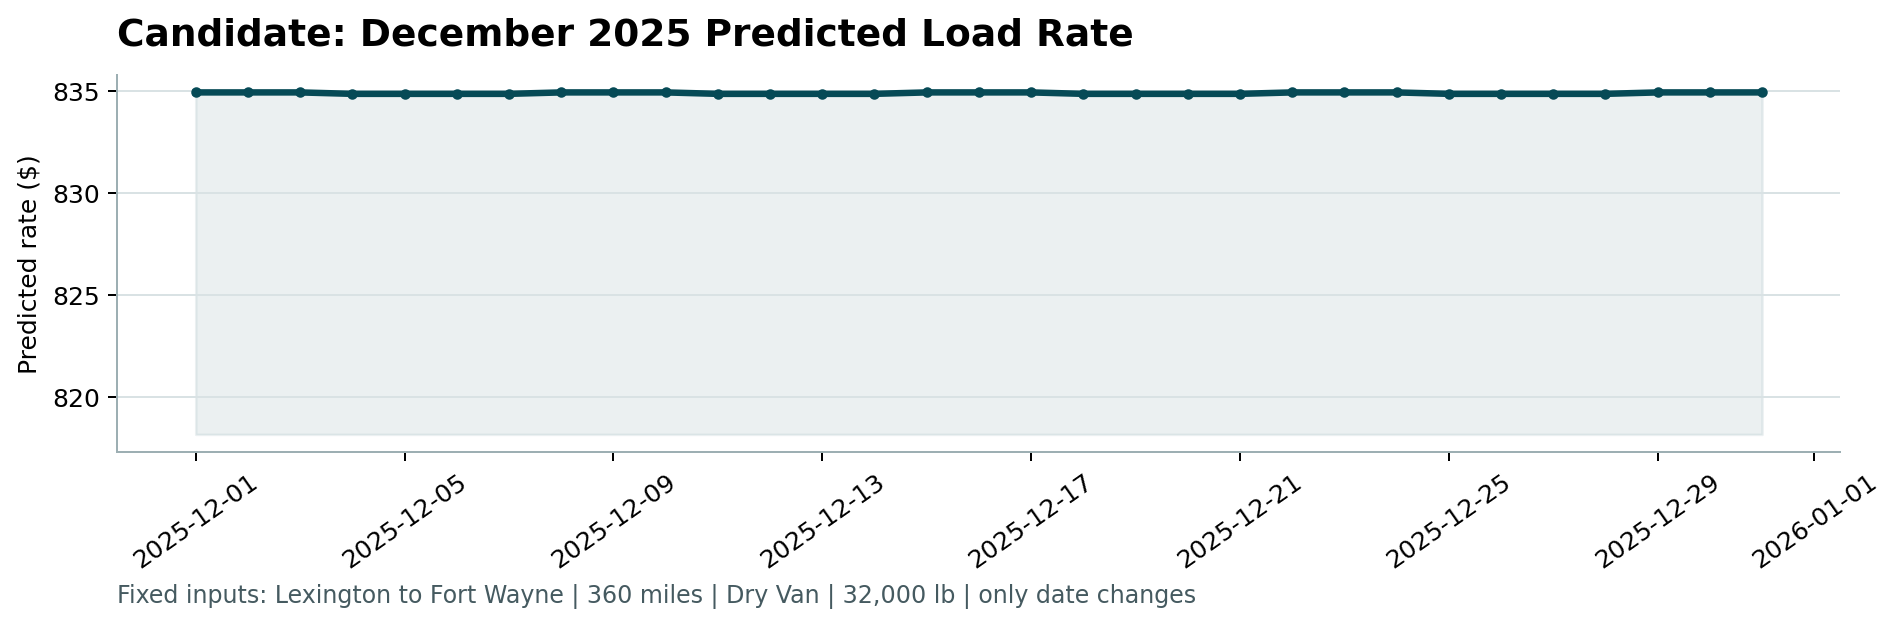

In [95]:
from IPython.display import Image, display

display(
    Image(
        "/content/freight-rate-prediction/scorer_results/candidate_december.png"
    )
)

In [96]:
from google.colab import files

files.download(
    "/content/freight-rate-prediction/validation_predictions.csv"
)

files.download(
    "/content/freight-rate-prediction/scorer_results/candidate_december.png"
)

files.download(
    "/content/freight-rate-prediction/data/december_chart_inputs.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>